# 🚢 Titanic - Machine Learning from Disaster

## Phase 8: Advanced Models & Ensemble Learning

### Objective

In the previous phases, we:

* Understood and cleaned the Titanic dataset.
* Performed exploratory data analysis.
* Engineered potentially useful features.
* Established baseline machine learning models.
* Evaluated engineered features through feature ablation.
* Tuned promising Scikit-learn models.

We are now ready to explore more advanced modeling techniques.

The objective of this notebook is to determine whether advanced gradient boosting algorithms and ensemble methods can improve predictive performance beyond our strongest tuned individual models.

---

# Advanced Models

We will investigate:

* XGBoost.
* LightGBM.
* CatBoost.

These algorithms are widely used for structured tabular machine learning problems.

---

# Ensemble Methods

A single model may perform well but still make systematic mistakes.

Different algorithms may learn different patterns from the same data.

If strong models make complementary errors, combining their predictions can improve generalization.

We will investigate:

1. Individual advanced models.
2. Out-of-fold probability predictions.
3. Prediction correlation.
4. Model disagreement.
5. Equal-weight probability averaging.
6. Weighted probability blending.
7. Simple soft-voting style ensembles.

# 1. Import Libraries

We begin by importing the libraries required

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import json
import joblib

from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict
)

from sklearn.metrics import (
    accuracy_score,
    log_loss,
    confusion_matrix,
    classification_report
)

from sklearn.compose import (
    ColumnTransformer
)

from sklearn.pipeline import (
    Pipeline
)

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import (
    SimpleImputer
)

import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

sns.set_theme(
    style="whitegrid"
)

print(
    "Core libraries imported successfully."
)

Core libraries imported successfully.


# 2. Define Project Paths

We will define the locations of:

* Processed datasets.
* Experiment results.
* Saved model pipelines.

These directories should match the structure used during the previous modeling notebooks.


In [2]:
data_dir = Path(
    "../data/processed"
)

results_dir = Path(
    "../results"
)

models_dir = Path(
    "../models"
)


results_dir.mkdir(
    parents=True,
    exist_ok=True
)

models_dir.mkdir(
    parents=True,
    exist_ok=True
)


print(
    f"Data directory: {data_dir}"
)

print(
    f"Results directory: {results_dir}"
)

print(
    f"Models directory: {models_dir}"
)

Data directory: ../data/processed
Results directory: ../results
Models directory: ../models


# 3. Load Feature-Engineered Data

We will load the feature-engineered training dataset.

The competition test dataset is not required for model evaluation in this notebook.

All model and ensemble decisions will be based on out-of-fold predictions generated from the training data.

This prevents the competition test set from influencing model-selection decisions.


In [3]:
train = pd.read_csv(
    data_dir /
    "train_featured.csv"
)


print(
    "Training dataset loaded successfully."
)

print(
    f"Shape: {train.shape}"
)

Training dataset loaded successfully.
Shape: (891, 26)


In [4]:
y = train[
    "Survived"
].copy()


print(
    "Target distribution:"
)

print(
    y.value_counts()
)

print(
    "\nTarget percentages:"
)

print(
    y.value_counts(
        normalize=True
    )
    .mul(100)
    .round(2)
)

Target distribution:
Survived
0    549
1    342
Name: count, dtype: int64

Target percentages:
Survived
0    61.62
1    38.38
Name: proportion, dtype: float64


# 4. Load Model Feature Mapping

During Phase 7, we saved the feature set associated with each tuned model.

Different model families may use different feature combinations.

We will load this mapping so that each tuned model receives exactly the same input features it used during hyperparameter tuning.


In [5]:
feature_mapping_path = (
    results_dir /
    "model_feature_mapping.json"
)


with open(
    feature_mapping_path,
    "r"
) as file:

    model_feature_mapping = (
        json.load(
            file
        )
    )


print(
    "Model feature mapping loaded."
)


for model_name, features in (
    model_feature_mapping.items()
):

    print(
        f"\n{model_name}: "
        f"{len(features)} features"
    )

Model feature mapping loaded.

Gradient Boosting: 13 features

Logistic Regression: 8 features

Random Forest: 21 features


# 5. Load Tuned Model Pipelines

The best tuned pipelines from Phase 7 were saved to the `models/` directory.

These pipelines already contain:

* Numerical preprocessing.
* Categorical preprocessing.
* One-hot encoding.
* The tuned classifier.

We will load these pipelines as our established competition candidates.

They will later be compared with the advanced boosting models.


In [6]:
tuned_model_paths = {

    "Logistic Regression":
        models_dir /
        "tuned_logistic_regression.pkl",

    "Random Forest":
        models_dir /
        "tuned_random_forest.pkl",

    "Gradient Boosting":
        models_dir /
        "tuned_gradient_boosting.pkl"
}


tuned_models = {}


for model_name, model_path in (
    tuned_model_paths.items()
):

    if model_path.exists():

        tuned_models[
            model_name
        ] = joblib.load(
            model_path
        )

        print(
            f"Loaded: {model_name}"
        )

    else:

        print(
            f"Not found: {model_path}"
        )

Loaded: Logistic Regression
Loaded: Random Forest
Loaded: Gradient Boosting


# 6. Define the Cross-Validation Strategy

We will use Stratified 5-Fold Cross-Validation with the same random seed used throughout the previous modeling phases.

The most important output in this notebook will be out-of-fold probability predictions.

For each passenger:

* The model is trained on four folds.
* The passenger belongs to the remaining validation fold.
* The model generates a survival probability for that passenger.

After all five folds are completed, every training passenger has a prediction generated by a model that did not train on that passenger.

These out-of-fold predictions provide the foundation for fair ensemble evaluation.


In [7]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


print(
    "Cross-validation strategy created."
)

Cross-validation strategy created.


# 7. Generate Out-of-Fold Predictions for Tuned Models

We will generate out-of-fold survival probabilities for each tuned Scikit-learn model.

Probability predictions are more useful than hard class predictions for ensemble construction.

For example:

A model might predict:

`0.51`

while another predicts:

`0.95`

Both would produce the hard prediction `1`, but their confidence levels are very different.

Probability averaging allows us to preserve this information when combining models.


In [8]:
oof_probabilities = {}

individual_results = []


for model_name, model in (
    tuned_models.items()
):

    print(
        f"Generating OOF predictions: "
        f"{model_name}"
    )


    selected_features = (
        model_feature_mapping[
            model_name
        ]
    )


    X_model = train[
        selected_features
    ].copy()


    probabilities = (
        cross_val_predict(
            model,
            X_model,
            y,
            cv=cv,
            method="predict_proba",
            n_jobs=-1
        )[:, 1]
    )


    predictions = (
        probabilities >= 0.5
    ).astype(int)


    oof_probabilities[
        model_name
    ] = probabilities


    individual_results.append({

        "Model":
            model_name,

        "OOF Accuracy":
            accuracy_score(
                y,
                predictions
            ),

        "OOF Log Loss":
            log_loss(
                y,
                probabilities
            )
    })


    print(
        f"Accuracy: "
        f"{accuracy_score(y, predictions):.4f}"
    )

Generating OOF predictions: Logistic Regression
Accuracy: 0.8361
Generating OOF predictions: Random Forest
Accuracy: 0.8541
Generating OOF predictions: Gradient Boosting
Accuracy: 0.8384


# 8. Check Advanced Model Availability

We will now check whether the following libraries are installed:

* XGBoost.
* LightGBM.
* CatBoost.

The notebook will continue even if one or more libraries are unavailable.

Only successfully imported models will be included in the experiments.


In [9]:
advanced_models_available = {}


try:

    from xgboost import (
        XGBClassifier
    )

    advanced_models_available[
        "XGBoost"
    ] = True

    print(
        "XGBoost is available."
    )

except ImportError:

    advanced_models_available[
        "XGBoost"
    ] = False

    print(
        "XGBoost is not installed."
    )


try:

    from lightgbm import (
        LGBMClassifier
    )

    advanced_models_available[
        "LightGBM"
    ] = True

    print(
        "LightGBM is available."
    )

except ImportError:

    advanced_models_available[
        "LightGBM"
    ] = False

    print(
        "LightGBM is not installed."
    )


try:

    from catboost import (
        CatBoostClassifier
    )

    advanced_models_available[
        "CatBoost"
    ] = True

    print(
        "CatBoost is available."
    )

except ImportError:

    advanced_models_available[
        "CatBoost"
    ] = False

    print(
        "CatBoost is not installed."
    )

XGBoost is not installed.
LightGBM is not installed.
CatBoost is not installed.


# 9. Define Features for Advanced Models

For the initial advanced-model experiments, we will use the complete engineered feature set.

This allows XGBoost, LightGBM, and CatBoost to evaluate a rich representation of the passenger information.

Later, if an advanced model performs strongly, its feature set can be optimized separately.

We will continue excluding raw high-cardinality identifiers such as:

* `PassengerId`
* `Name`
* `Ticket`
* `Cabin`

Useful information extracted from these variables is already represented through engineered features.


In [10]:
advanced_features = [

    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",

    "Title",

    "FamilySize",
    "IsAlone",
    "FamilyCategory",

    "CabinKnown",
    "Deck",

    "TicketGroupSize",
    "TicketPrefix",
    "FarePerPerson",
    "LogFare",

    "AgeMissing",
    "IsChild",
    "AgeGroup",

    "Sex_Pclass"
]


X_advanced = train[
    advanced_features
].copy()


print(
    f"Advanced model features: "
    f"{len(advanced_features)}"
)

Advanced model features: 21


In [11]:
advanced_categorical_features = [

    "Pclass",
    "Sex",
    "Embarked",
    "Title",
    "FamilyCategory",
    "Deck",
    "TicketPrefix",
    "AgeGroup",
    "Sex_Pclass"
]


advanced_numerical_features = [

    feature
    for feature
    in advanced_features
    if feature
    not in advanced_categorical_features
]


advanced_numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)


advanced_categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


advanced_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            advanced_numeric_transformer,
            advanced_numerical_features
        ),
        (
            "categorical",
            advanced_categorical_transformer,
            advanced_categorical_features
        )
    ]
)


print(
    "Advanced preprocessing pipeline created."
)

Advanced preprocessing pipeline created.


# 10. Define Advanced Gradient Boosting Models

We will begin with conservative model configurations rather than performing another large hyperparameter search immediately.

The objective is first to determine whether these model families are competitive with our tuned Scikit-learn models.

If an advanced model performs strongly, further tuning can be justified later.

The configurations below include moderate regularization to reduce the risk of severe overfitting on the relatively small Titanic dataset.


In [12]:
advanced_models = {}


if advanced_models_available[
    "XGBoost"
]:

    advanced_models[
        "XGBoost"
    ] = XGBClassifier(

        n_estimators=300,

        learning_rate=0.03,

        max_depth=3,

        min_child_weight=3,

        subsample=0.8,

        colsample_bytree=0.8,

        reg_alpha=0.1,

        reg_lambda=1.0,

        eval_metric="logloss",

        random_state=42,

        n_jobs=-1
    )


if advanced_models_available[
    "LightGBM"
]:

    advanced_models[
        "LightGBM"
    ] = LGBMClassifier(

        n_estimators=300,

        learning_rate=0.03,

        num_leaves=15,

        max_depth=5,

        min_child_samples=20,

        subsample=0.8,

        colsample_bytree=0.8,

        reg_alpha=0.1,

        reg_lambda=1.0,

        random_state=42,

        verbose=-1
    )


if advanced_models_available[
    "CatBoost"
]:

    advanced_models[
        "CatBoost"
    ] = CatBoostClassifier(

        iterations=300,

        learning_rate=0.03,

        depth=5,

        l2_leaf_reg=5,

        loss_function="Logloss",

        verbose=0,

        random_seed=42,

        thread_count=-1
    )


print(
    "Advanced models:"
)


for model_name in advanced_models:

    print(
        f"- {model_name}"
    )

Advanced models:


# 11. Evaluate Advanced Models Using OOF Predictions

Each advanced model will be combined with the preprocessing pipeline.

We will then generate out-of-fold survival probabilities using the same cross-validation folds used for the tuned models.

Using identical folds is essential because it allows direct comparison and enables us to combine model probabilities passenger by passenger.


In [13]:
advanced_pipelines = {}


for model_name, model in (
    advanced_models.items()
):

    print(
        "\n"
        + "=" * 60
    )

    print(
        f"Evaluating: {model_name}"
    )

    print(
        "=" * 60
    )


    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                advanced_preprocessor
            ),
            (
                "classifier",
                model
            )
        ]
    )


    advanced_pipelines[
        model_name
    ] = pipeline


    probabilities = (
        cross_val_predict(
            pipeline,
            X_advanced,
            y,
            cv=cv,
            method="predict_proba",
            n_jobs=-1
        )[:, 1]
    )


    predictions = (
        probabilities >= 0.5
    ).astype(int)


    oof_probabilities[
        model_name
    ] = probabilities


    individual_results.append({

        "Model":
            model_name,

        "OOF Accuracy":
            accuracy_score(
                y,
                predictions
            ),

        "OOF Log Loss":
            log_loss(
                y,
                probabilities
            )
    })


    print(
        f"OOF Accuracy: "
        f"{accuracy_score(y, predictions):.4f}"
    )


    print(
        f"OOF Log Loss: "
        f"{log_loss(y, probabilities):.4f}"
    )

# 12. Compare Individual Model Performance

We will now compare every available individual model using:

### OOF Accuracy

Measures how often the predicted class is correct using a probability threshold of `0.5`.

### OOF Log Loss

Evaluates the quality of probability predictions.

A model that is confidently wrong receives a larger penalty.

For ensemble construction, probability quality is important because we will combine predicted probabilities rather than only hard class labels.


In [14]:
individual_results_df = (
    pd.DataFrame(
        individual_results
    )
    .sort_values(
        "OOF Accuracy",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


individual_results_df.round(4)

,Model,OOF Accuracy,OOF Log Loss
0,Random Forest,0.8541,0.3949
1,Gradient Boosting,0.8384,0.4016
2,Logistic Regression,0.8361,0.4141


In [15]:
oof_df = pd.DataFrame(
    oof_probabilities
)


oof_df[
    "Actual"
] = y.values


print(
    f"OOF prediction shape: "
    f"{oof_df.shape}"
)


oof_df.head()

OOF prediction shape: (891, 4)


,Logistic Regression,Random Forest,Gradient Boosting,Actual
0,0.066524,0.078323,0.079839,0
1,0.955414,0.991477,0.954953,1
2,0.602478,0.534188,0.322650,1
3,0.943846,0.996255,0.962740,1
4,0.075100,0.084243,0.127848,0


# 13. Analyze Model Prediction Correlation

Before building ensembles, we need to understand how similar the models are.

If two models produce nearly identical probability predictions, combining them may provide limited additional value.

Lower correlation between strong models can indicate useful prediction diversity.

However, low correlation alone is not sufficient.

A weak model may also have low correlation simply because its predictions are poor.

The most promising ensemble components are models that combine:

* Strong individual performance.
* Reasonable probability calibration.
* Complementary prediction behavior.


In [16]:
probability_columns = list(
    oof_probabilities.keys()
)


correlation_matrix = (
    oof_df[
        probability_columns
    ]
    .corr()
)


correlation_matrix.round(3)

,Logistic Regression,Random Forest,Gradient Boosting
Logistic Regression,1.000,0.895,0.906
Random Forest,0.895,1.000,0.965
Gradient Boosting,0.906,0.965,1.000


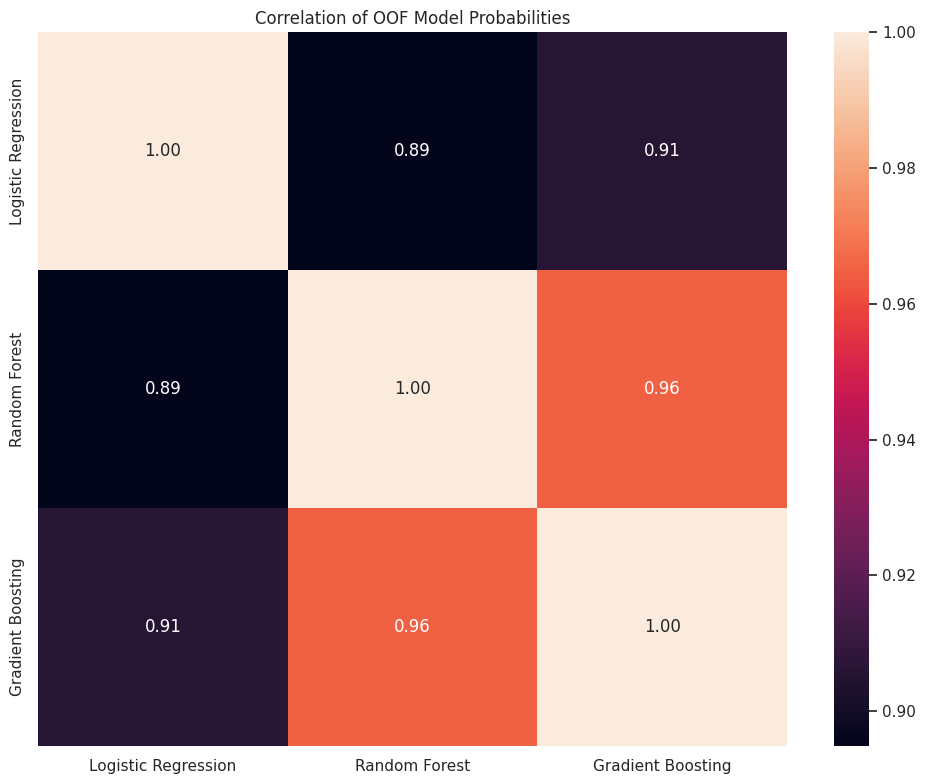

In [17]:
plt.figure(
    figsize=(10, 8)
)


sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)


plt.title(
    "Correlation of OOF Model Probabilities"
)


plt.tight_layout()

plt.show()

# 14. Analyze Model Prediction Agreement

Probability correlation provides one perspective on model similarity.

We will also compare hard predictions.

For every pair of models, we calculate the percentage of passengers for whom both models produce the same predicted class.

A lower agreement rate between two strong models may indicate that they make different decisions on difficult passengers.

Such differences can sometimes make ensemble methods more effective.


In [18]:
hard_predictions = {}


for model_name, probabilities in (
    oof_probabilities.items()
):

    hard_predictions[
        model_name
    ] = (
        probabilities >= 0.5
    ).astype(int)


agreement_matrix = pd.DataFrame(
    index=probability_columns,
    columns=probability_columns,
    dtype=float
)


for model_a in probability_columns:

    for model_b in probability_columns:

        agreement = np.mean(

            hard_predictions[
                model_a
            ]

            ==

            hard_predictions[
                model_b
            ]
        )


        agreement_matrix.loc[
            model_a,
            model_b
        ] = agreement


agreement_matrix.round(3)

,Logistic Regression,Random Forest,Gradient Boosting
Logistic Regression,1.000,0.906,0.912
Random Forest,0.906,1.000,0.939
Gradient Boosting,0.912,0.939,1.000


# 15. Build an Equal-Weight Probability Ensemble

Our first ensemble will be intentionally simple.

We will average the predicted survival probabilities from all available candidate models.

If there are `N` models:

`Ensemble Probability = (P1 + P2 + ... + PN) / N`

The final class prediction is:

* `1` if the average probability is at least `0.5`.
* `0` otherwise.

This provides a useful ensemble baseline before experimenting with optimized weights.


In [19]:
all_probability_matrix = np.column_stack(

    [
        oof_probabilities[
            model_name
        ]

        for model_name
        in probability_columns
    ]
)


equal_weight_probabilities = (
    all_probability_matrix.mean(
        axis=1
    )
)


equal_weight_predictions = (
    equal_weight_probabilities
    >= 0.5
).astype(int)


equal_weight_accuracy = (
    accuracy_score(
        y,
        equal_weight_predictions
    )
)


equal_weight_log_loss = (
    log_loss(
        y,
        equal_weight_probabilities
    )
)


print(
    f"Equal-Weight Ensemble Accuracy: "
    f"{equal_weight_accuracy:.4f}"
)


print(
    f"Equal-Weight Ensemble Log Loss: "
    f"{equal_weight_log_loss:.4f}"
)

Equal-Weight Ensemble Accuracy: 0.8519
Equal-Weight Ensemble Log Loss: 0.3821


In [20]:
best_individual_accuracy = (
    individual_results_df[
        "OOF Accuracy"
    ].max()
)


best_individual_name = (
    individual_results_df
    .iloc[0][
        "Model"
    ]
)


print(
    f"Best Individual Model: "
    f"{best_individual_name}"
)


print(
    f"Best Individual Accuracy: "
    f"{best_individual_accuracy:.4f}"
)


print(
    f"Equal-Weight Ensemble Accuracy: "
    f"{equal_weight_accuracy:.4f}"
)


print(
    f"Difference: "
    f"{equal_weight_accuracy - best_individual_accuracy:+.4f}"
)

Best Individual Model: Random Forest
Best Individual Accuracy: 0.8541
Equal-Weight Ensemble Accuracy: 0.8519
Difference: -0.0022


# 16. Evaluate Top-Model Ensembles

An ensemble does not necessarily improve when more models are added.

A weaker or highly correlated model can reduce ensemble performance.

We will therefore rank the individual models by OOF accuracy and evaluate ensembles containing:

* Top 2 models.
* Top 3 models.
* Top 4 models.
* Additional models if available.

Each ensemble will initially use equal probability weights.

This helps us determine whether ensemble performance improves as additional models are included.


In [21]:
ranked_models = (
    individual_results_df[
        "Model"
    ]
    .tolist()
)


top_n_ensemble_results = []


for n_models in range(
    2,
    len(ranked_models) + 1
):

    selected_models = (
        ranked_models[
            :n_models
        ]
    )


    probability_matrix = (
        np.column_stack(

            [
                oof_probabilities[
                    model_name
                ]

                for model_name
                in selected_models
            ]
        )
    )


    ensemble_probabilities = (
        probability_matrix.mean(
            axis=1
        )
    )


    ensemble_predictions = (
        ensemble_probabilities
        >= 0.5
    ).astype(int)


    top_n_ensemble_results.append({

        "N Models":
            n_models,

        "Models":
            " + ".join(
                selected_models
            ),

        "OOF Accuracy":
            accuracy_score(
                y,
                ensemble_predictions
            ),

        "OOF Log Loss":
            log_loss(
                y,
                ensemble_probabilities
            )
    })


top_n_df = pd.DataFrame(
    top_n_ensemble_results
)


top_n_df.round(4)

,N Models,Models,OOF Accuracy,OOF Log Loss
0,2,Random Forest + Gradient Boosting,0.8474,0.3871
1,3,Random Forest + Gradient Boosting + Logistic R...,0.8519,0.3821


In [22]:
best_equal_ensemble = (
    top_n_df
    .sort_values(
        "OOF Accuracy",
        ascending=False
    )
    .iloc[0]
)


print(
    "BEST EQUAL-WEIGHT ENSEMBLE"
)

print(
    "-" * 60
)


print(
    f"Models: "
    f"{best_equal_ensemble['Models']}"
)


print(
    f"Accuracy: "
    f"{best_equal_ensemble['OOF Accuracy']:.4f}"
)


print(
    f"Log Loss: "
    f"{best_equal_ensemble['OOF Log Loss']:.4f}"
)

BEST EQUAL-WEIGHT ENSEMBLE
------------------------------------------------------------
Models: Random Forest + Gradient Boosting + Logistic Regression
Accuracy: 0.8519
Log Loss: 0.3821


# 17. Weighted Probability Blending

Equal weighting assumes that every model should contribute equally.

This may not be optimal.

A stronger model may deserve more influence, while a weaker but diverse model may still provide useful complementary information.

We will perform a controlled weight search using the top three individual models.

The weights must satisfy:

`w1 + w2 + w3 = 1`

We will evaluate combinations using increments of `0.05`.

For every weight combination:

1. Calculate the weighted survival probability.
2. Convert probabilities to class predictions using a `0.5` threshold.
3. Calculate OOF accuracy.
4. Calculate OOF log loss.

Because the same OOF predictions are being used to select the weights, the best weighted result may be optimistic.

The optimized weights should therefore be treated as a candidate ensemble configuration rather than guaranteed future performance.


In [23]:
top_three_models = (
    ranked_models[
        :3
    ]
)


print(
    "Models selected for weight search:"
)


for model_name in top_three_models:

    print(
        f"- {model_name}"
    )

Models selected for weight search:
- Random Forest
- Gradient Boosting
- Logistic Regression


In [24]:
weight_results = []


model_1 = top_three_models[0]

model_2 = top_three_models[1]

model_3 = top_three_models[2]


p1 = oof_probabilities[
    model_1
]

p2 = oof_probabilities[
    model_2
]

p3 = oof_probabilities[
    model_3
]


weight_values = np.arange(
    0,
    1.01,
    0.05
)


for w1 in weight_values:

    for w2 in weight_values:

        w3 = (
            1.0
            -
            w1
            -
            w2
        )


        if w3 < 0:

            continue


        if w3 > 1:

            continue


        blended_probabilities = (

            w1 * p1

            +

            w2 * p2

            +

            w3 * p3
        )


        blended_predictions = (
            blended_probabilities
            >= 0.5
        ).astype(int)


        weight_results.append({

            f"Weight_{model_1}":
                w1,

            f"Weight_{model_2}":
                w2,

            f"Weight_{model_3}":
                w3,

            "OOF Accuracy":
                accuracy_score(
                    y,
                    blended_predictions
                ),

            "OOF Log Loss":
                log_loss(
                    y,
                    blended_probabilities
                )
        })


weight_results_df = pd.DataFrame(
    weight_results
)


print(
    f"Weight combinations tested: "
    f"{len(weight_results_df)}"
)

Weight combinations tested: 218


In [25]:
best_weight_results = (
    weight_results_df
    .sort_values(
        [
            "OOF Accuracy",
            "OOF Log Loss"
        ],
        ascending=[
            False,
            True
        ]
    )
    .reset_index(
        drop=True
    )
)


best_weight_results.head(10).round(4)

,Weight_Random Forest,Weight_Gradient Boosting,Weight_Logistic Regression,OOF Accuracy,OOF Log Loss
0,0.50,0.20,0.30,0.8541,0.3801
1,0.60,0.20,0.20,0.8541,0.3801
2,0.75,0.05,0.20,0.8541,0.3802
3,0.45,0.25,0.30,0.8541,0.3805
4,0.45,0.30,0.25,0.8541,0.3807
5,0.40,0.30,0.30,0.8541,0.3811
6,0.40,0.35,0.25,0.8541,0.3814
7,1.00,0.00,0.00,0.8541,0.3949
8,0.70,0.05,0.25,0.8530,0.3796
9,0.70,0.10,0.20,0.8530,0.3800


In [26]:
best_weights = (
    best_weight_results
    .iloc[0]
)


w1 = best_weights[
    f"Weight_{model_1}"
]

w2 = best_weights[
    f"Weight_{model_2}"
]

w3 = best_weights[
    f"Weight_{model_3}"
]


best_blend_probabilities = (

    w1 * p1

    +

    w2 * p2

    +

    w3 * p3
)


best_blend_predictions = (
    best_blend_probabilities
    >= 0.5
).astype(int)


best_blend_accuracy = (
    accuracy_score(
        y,
        best_blend_predictions
    )
)


best_blend_log_loss = (
    log_loss(
        y,
        best_blend_probabilities
    )
)


print(
    "BEST WEIGHTED BLEND"
)

print(
    "-" * 60
)


print(
    f"{model_1}: {w1:.2f}"
)

print(
    f"{model_2}: {w2:.2f}"
)

print(
    f"{model_3}: {w3:.2f}"
)


print(
    f"\nOOF Accuracy: "
    f"{best_blend_accuracy:.4f}"
)


print(
    f"OOF Log Loss: "
    f"{best_blend_log_loss:.4f}"
)

BEST WEIGHTED BLEND
------------------------------------------------------------
Random Forest: 0.50
Gradient Boosting: 0.20
Logistic Regression: 0.30

OOF Accuracy: 0.8541
OOF Log Loss: 0.3801


# 18. Compare Individual Models and Ensembles

We will now create a final comparison containing:

* Every individual candidate model.
* The equal-weight ensemble using all models.
* The strongest top-N equal-weight ensemble.
* The optimized three-model weighted blend.

This comparison will help us identify the strongest candidates to carry into final Kaggle submission experiments.


In [27]:
final_comparison = (
    individual_results_df
    .copy()
)


ensemble_rows = pd.DataFrame({

    "Model": [

        "Equal Weight - All Models",

        "Best Top-N Equal Ensemble",

        "Optimized Weighted Blend"
    ],

    "OOF Accuracy": [

        equal_weight_accuracy,

        best_equal_ensemble[
            "OOF Accuracy"
        ],

        best_blend_accuracy
    ],

    "OOF Log Loss": [

        equal_weight_log_loss,

        best_equal_ensemble[
            "OOF Log Loss"
        ],

        best_blend_log_loss
    ]
})


final_comparison = pd.concat(

    [
        final_comparison,
        ensemble_rows
    ],

    ignore_index=True
)


final_comparison = (
    final_comparison
    .sort_values(
        "OOF Accuracy",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


final_comparison.round(4)

,Model,OOF Accuracy,OOF Log Loss
0,Random Forest,0.8541,0.3949
1,Optimized Weighted Blend,0.8541,0.3801
2,Best Top-N Equal Ensemble,0.8519,0.3821
3,Equal Weight - All Models,0.8519,0.3821
4,Gradient Boosting,0.8384,0.4016
5,Logistic Regression,0.8361,0.4141


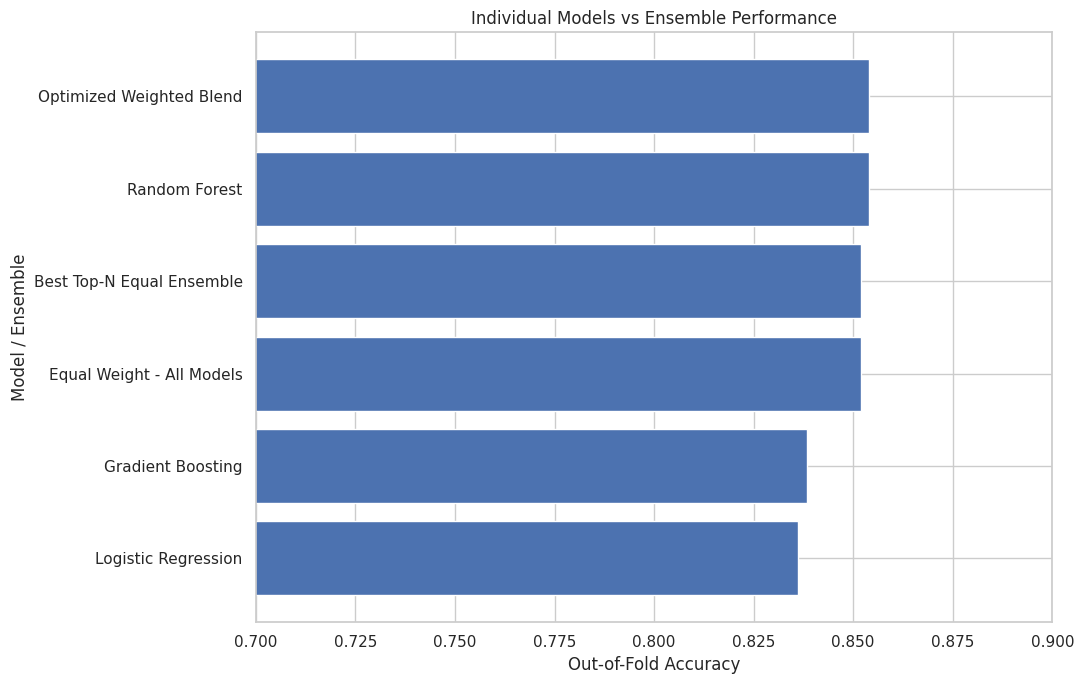

In [28]:
plot_df = (
    final_comparison
    .sort_values(
        "OOF Accuracy",
        ascending=True
    )
)


plt.figure(
    figsize=(11, 7)
)


plt.barh(
    plot_df[
        "Model"
    ],
    plot_df[
        "OOF Accuracy"
    ]
)


plt.xlabel(
    "Out-of-Fold Accuracy"
)


plt.ylabel(
    "Model / Ensemble"
)


plt.title(
    "Individual Models vs Ensemble Performance"
)


plt.xlim(
    0.70,
    0.90
)


plt.tight_layout()

plt.show()

# 19. Analyze the Best Weighted Ensemble

We will inspect the confusion matrix and classification report for the optimized weighted blend.

This allows us to determine whether the ensemble improves overall accuracy by:

* Correctly identifying more survivors.
* Correctly identifying more non-survivors.
* Reducing false positives.
* Reducing false negatives.

Accuracy alone cannot reveal these differences.


In [29]:
cm = confusion_matrix(
    y,
    best_blend_predictions
)


cm_df = pd.DataFrame(

    cm,

    index=[
        "Actual: Did Not Survive",
        "Actual: Survived"
    ],

    columns=[
        "Predicted: Did Not Survive",
        "Predicted: Survived"
    ]
)


cm_df

,Predicted: Did Not Survive,Predicted: Survived
Actual: Did Not Survive,495,54
Actual: Survived,76,266


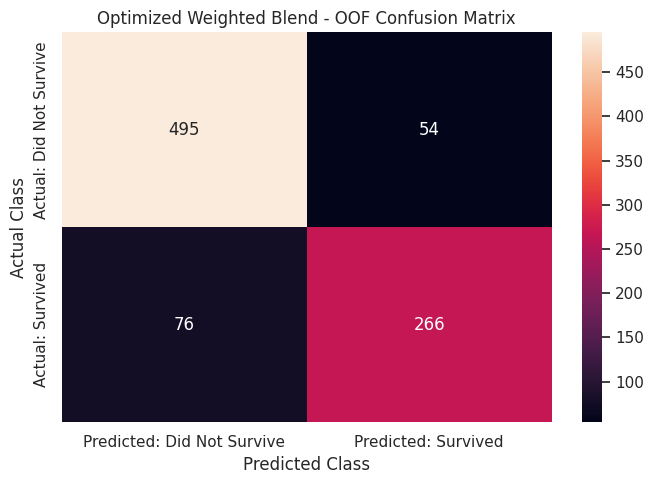

In [30]:
plt.figure(
    figsize=(7, 5)
)


sns.heatmap(
    cm_df,
    annot=True,
    fmt="d"
)


plt.title(
    "Optimized Weighted Blend - OOF Confusion Matrix"
)


plt.ylabel(
    "Actual Class"
)


plt.xlabel(
    "Predicted Class"
)


plt.tight_layout()

plt.show()

In [31]:
print(

    classification_report(

        y,

        best_blend_predictions,

        target_names=[

            "Did Not Survive",

            "Survived"
        ]
    )
)

                 precision    recall  f1-score   support

Did Not Survive       0.87      0.90      0.88       549
       Survived       0.83      0.78      0.80       342

       accuracy                           0.85       891
      macro avg       0.85      0.84      0.84       891
   weighted avg       0.85      0.85      0.85       891



# 20. Save Out-of-Fold Predictions

We will save the out-of-fold probabilities generated by every candidate model.

These predictions are valuable because they can later be used for:

* Additional ensemble experiments.
* Stacking experiments.
* Threshold optimization.
* Error analysis.
* Reproducibility.

We will also save the actual target and the optimized blend probability.


In [32]:
oof_output = (
    oof_df.copy()
)


oof_output[
    "Optimized_Blend"
] = best_blend_probabilities


oof_output.to_csv(

    results_dir /
    "advanced_model_oof_predictions.csv",

    index=False
)


print(
    "OOF predictions saved successfully."
)

OOF predictions saved successfully.


In [33]:
individual_results_df.to_csv(

    results_dir /
    "advanced_individual_model_results.csv",

    index=False
)


final_comparison.to_csv(

    results_dir /
    "advanced_ensemble_comparison.csv",

    index=False
)


weight_results_df.to_csv(

    results_dir /
    "ensemble_weight_search.csv",

    index=False
)


print(
    "Advanced model and ensemble results saved."
)

Advanced model and ensemble results saved.


# 21. Save the Best Ensemble Configuration

The final competition notebook will need to know:

* Which models are included in the optimized blend.
* The weight assigned to each model.

We will save this information as a JSON file.

This avoids manually copying ensemble weights into the final submission notebook.


In [34]:
ensemble_configuration = {

    "models": [

        model_1,

        model_2,

        model_3
    ],

    "weights": {

        model_1:
            float(w1),

        model_2:
            float(w2),

        model_3:
            float(w3)
    },

    "oof_accuracy":
        float(
            best_blend_accuracy
        ),

    "oof_log_loss":
        float(
            best_blend_log_loss
        )
}


ensemble_config_path = (

    results_dir /
    "best_ensemble_config.json"
)


with open(

    ensemble_config_path,

    "w"

) as file:

    json.dump(

        ensemble_configuration,

        file,

        indent=4
    )


print(
    f"Ensemble configuration saved to:"
)


print(
    ensemble_config_path
)

Ensemble configuration saved to:
../results/best_ensemble_config.json


In [35]:
for model_name, pipeline in (
    advanced_pipelines.items()
):

    safe_name = (

        model_name

        .lower()

        .replace(
            " ",
            "_"
        )
    )


    model_path = (

        models_dir /

        f"advanced_{safe_name}_pipeline.pkl"
    )


    joblib.dump(

        pipeline,

        model_path
    )


    print(
        f"Saved pipeline template: "
        f"{model_path}"
    )

# 22. Phase 8 Evaluation

After completing this notebook, evaluate the results carefully.

## Question 1: Did Advanced Models Beat the Tuned Scikit-learn Models?

Compare the OOF accuracy and log loss of:

* Logistic Regression.
* Random Forest.
* Gradient Boosting.
* XGBoost.
* LightGBM.
* CatBoost.

An advanced algorithm should not automatically be preferred simply because it is more sophisticated.

It should demonstrate stronger validation performance.

---

## Question 2: Are the Strongest Models Diverse?

Inspect:

* Probability correlation.
* Hard prediction agreement.

Two strong models with slightly different prediction patterns may be better ensemble candidates than two nearly identical models.

---

## Question 3: Did Equal-Weight Averaging Help?

Compare the equal-weight ensemble against the strongest individual model.

If the ensemble performs worse, some included models may be weakening the combined prediction.

---

## Question 4: Did the Top-N Ensemble Help?

Determine whether combining only the strongest models performs better than combining every available model.

This can indicate whether weaker models should be excluded.

---

## Question 5: Did Weight Optimization Help?

Compare:

* Best individual model.
* Equal-weight ensemble.
* Optimized weighted blend.

Remember that the optimized weights were selected using the same OOF predictions used to evaluate them.

Therefore, small improvements should be interpreted cautiously.

---

## Question 6: Is the Ensemble Improvement Meaningful?

A difference of a few correct predictions can change Titanic accuracy by several thousandths.

For example, an improvement from:

`0.8305`

to:

`0.8339`

may represent only a few passengers.

Such improvements are useful, but they do not guarantee a higher Kaggle leaderboard score.

Our final submission strategy should therefore test several evidence-based model candidates rather than relying on one supposedly perfect model.


# 23. Phase 8 Summary

In this notebook, we moved beyond individual baseline models and explored advanced modeling and ensemble learning.

---

## Tuned Model Candidates

We loaded the tuned Scikit-learn pipelines created during Phase 7 and generated out-of-fold probability predictions for each model.

---

## Advanced Gradient Boosting

Depending on package availability, we evaluated:

* XGBoost.
* LightGBM.
* CatBoost.

Each advanced model was evaluated using the same Stratified 5-Fold Cross-Validation strategy.

---

## Out-of-Fold Probabilities

For every model, we generated probability predictions for passengers that were not included in that model's training fold.

These predictions provided a fair foundation for comparing and combining models.

---

## Model Diversity

We examined:

* Probability correlation.
* Hard prediction agreement.

This helped us determine whether strong models learned complementary patterns.

---

## Equal-Weight Ensembles

We evaluated:

* An ensemble containing all available models.
* Ensembles containing only the top-ranked models.

This tested whether adding additional models improved or weakened ensemble performance.

---

## Weighted Probability Blending

We selected the three strongest individual models and searched for weighted probability combinations.

The best configuration was selected according to:

1. OOF accuracy.
2. OOF log loss as a tie-breaker.

---

## Saved Artifacts

We saved:

* Individual model results.
* Ensemble comparison results.
* Out-of-fold probabilities.
* Ensemble weight-search results.
* Best ensemble configuration.
* Advanced model pipeline configurations.

These artifacts will be used during the final competition phase.